Denna notebook innehåller kod för analys av om extrema händelser tenderar att inträffa oftare eller vara mer omfattande i samband med kvartalsrapporter. Koden hämtar aktiekurser, kompletterar kvartalsrapportdatum, beräknar dagliga log-förluster och delar upp observationerna i rapportfönster respektive icke-rapportfönster. Därefter används tröskelval, avklustring, frekvensjämförelser, GPD-anpassning, QQ-plottar, return level-plottar och tester för skillnader i svansindex mellan grupperna.

Analysen påbörjades i början av projektet, men den färdigställdes inte i rapporten eftersom arbetet behövde avgränsas. Koden sparas därför främst som dokumentation av den metodik som undersöktes, snarare än som underlag för rapportens slutliga resultat.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import math

In [5]:
# Datum för kvartalsrapporter, Investor, via import från textfil
# Detta görs då datum saknas i Yfinance

# dataläsning investor
with open("datum kvartalsrapporter Investor.txt") as f:
    inv_text = f.read()

# Kompletterande kvartalsdatum
datum_investor = re.findall(r"\d{4}-\d{2}-\d{2}", inv_text) #letar datum i textfilen, r:et gör "\d" tolkningsbart av regex

In [8]:
# Aktier att studera, sparade i en wrapper
aktie_skräp = "AZN.ST SHB-A.ST VOLV-B.ST"

aktier = "INVE-B.ST \
          SEB-A.ST \
          NDA-SE.ST \
          CAST.ST \
          SKA-B.ST \
          ABB.ST \
          ATCO-A.ST \
          BOL.ST \
          SCA-B.ST"

# som separerare
ticker_dict = yf.Tickers(aktier).tickers

# Sätt period
start = "2000-01-01"
end = "2026-03-31"

# Price data
price_dict = {} # key-value map av dataframes
date_dict = {} # key-value map av rapportdatum
for key in list(ticker_dict.keys()):
  if key == "NDA-SE.ST": # sammanslagning till nordea skedde stegvis 1997-2000 men sista förändring under 2000
    current = ticker_dict[key].history(start = "2001-01-01", \
                                      end = end)
  else:
    current = ticker_dict[key].history(start = start, \
                                      end = end)
  current.index = current.index.tz_localize(None).normalize()
  price_dict[key] = current[current["Volume"] > 0]
  if key == "AZN.ST":
    date_dict[key] = yf.Ticker("AZN").get_earnings_dates(limit=100)\
                    .index.tz_localize(None)\
                    .normalize()
  elif key == "INVE-B.ST":
    date_dict[key] = pd.to_datetime(datum_investor)
  elif key == "ABB.ST":
    date_dict[key] = yf.Ticker("ABBN.SW").get_earnings_dates(limit=100)\
                    .index.tz_localize(None)\
                    .normalize()
  else:
    date_dict[key] = ticker_dict[key].get_earnings_dates(limit=100)\
                    .index.tz_localize(None)\
                    .normalize()

for key in list(date_dict.keys()):
  print("key is", key)
  print("antalet rapportdatum är", len(list(date_dict[key])))

key is INVE-B.ST
antalet rapportdatum är 104
key is SEB-A.ST
antalet rapportdatum är 89
key is NDA-SE.ST
antalet rapportdatum är 89
key is CAST.ST
antalet rapportdatum är 87
key is SKA-B.ST
antalet rapportdatum är 88
key is ABB.ST
antalet rapportdatum är 89
key is ATCO-A.ST
antalet rapportdatum är 89
key is BOL.ST
antalet rapportdatum är 100
key is SCA-B.ST
antalet rapportdatum är 89


In [9]:
for key in list(date_dict.keys()):
  print(f"\nAktie '{key}' med första dagum '{date_dict[key][-1]}' och sista datum '{date_dict[key][0]}'")


Aktie 'INVE-B.ST' med första dagum '2000-04-12 00:00:00' och sista datum '2026-01-22 00:00:00'

Aktie 'SEB-A.ST' med första dagum '2004-07-27 00:00:00' och sista datum '2026-07-15 00:00:00'

Aktie 'NDA-SE.ST' med första dagum '2004-08-18 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'CAST.ST' med första dagum '2005-01-27 00:00:00' och sista datum '2026-07-15 00:00:00'

Aktie 'SKA-B.ST' med första dagum '2004-10-29 00:00:00' och sista datum '2026-07-17 00:00:00'

Aktie 'ABB.ST' med första dagum '2004-07-29 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'ATCO-A.ST' med första dagum '2004-07-16 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'BOL.ST' med första dagum '2000-06-29 00:00:00' och sista datum '2026-07-21 00:00:00'

Aktie 'SCA-B.ST' med första dagum '2004-07-21 00:00:00' och sista datum '2026-07-22 00:00:00'


In [14]:
# Kompletterande datum, efter datastäd

# dataläsning SHB
with open("datum handelsbanken.txt") as f:
  shb_text = f.read()

# dataläsing SEB
with open("datum seb.txt") as f:
  seb_text = f.read()

# dataläsning NDA
with open("datum nordea.txt") as f:
  nda_text = f.read()

# dataläsning CAST
with open("CAST datum.txt") as f:
  cast_text = f.read()

# SKA
with open("datum skanska.txt") as f:
  ska_text = f.read()

# VOLV
with open("datum volvo.txt") as f:
  volv_text = f.read()

# abb
with open("datum abb.txt") as f:
  abb_text = f.read()

# ATCO
with open("datum atlascopco.txt") as f:
  atco_text = f.read()

# BOL
with open("datum boliden.txt") as f:
  bol_text = f.read()

with open("datum sca.txt") as f:
  sca_text = f.read()



In [19]:
## Datumkomplettering av de aktier som inte hade hela perioden

# SEB
dates_seb_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", seb_text))
dates_seb_tot = dates_seb_add.union(date_dict["SEB-A.ST"]).sort_values(ascending=False)

# NDA
dates_nda_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", nda_text))
dates_nda_tot = dates_nda_add.union(date_dict["NDA-SE.ST"]).sort_values(ascending=False)

# CAST
dates_cast_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", cast_text))
dates_cast_tot = dates_cast_add.union(date_dict["CAST.ST"]).sort_values(ascending=False)

# SKA
dates_ska_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", ska_text))
dates_ska_tot = dates_ska_add.union(date_dict["SKA-B.ST"]).sort_values(ascending=False)

# abb
dates_abb_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", abb_text))
dates_abb_tot = dates_abb_add.union(date_dict["ABB.ST"]).sort_values(ascending=False)

# ATCO
dates_atco_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", atco_text))
dates_atco_tot = dates_atco_add.union(date_dict["ATCO-A.ST"]).sort_values(ascending=False)

# BOL
dates_bol_part = date_dict["BOL.ST"][0:len(date_dict["BOL.ST"])-3]   # Tar bort de tre sista - dessa har inte kunnat verifieras via
                                                                     # bolidens egna sida
dates_bol_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", bol_text))
dates_bol_tot = dates_bol_add.union(dates_bol_part).sort_values(ascending=False)

# SCA
dates_sca_add = pd.DatetimeIndex(re.findall(r"\d{4}-\d{2}-\d{2}", sca_text))
dates_sca_tot = dates_sca_add.union(date_dict["SCA-B.ST"]).sort_values(ascending=False)


date_dict_complete = {}
date_dict_complete["INVE-B.ST"] = date_dict["INVE-B.ST"]
date_dict_complete["SEB-A.ST"] = dates_seb_tot
date_dict_complete["NDA-SE.ST"] = dates_nda_tot
date_dict_complete["CAST.ST"] = dates_cast_tot
date_dict_complete["SKA-B.ST"] = dates_ska_tot
date_dict_complete["ABB.ST"] = dates_abb_tot
date_dict_complete["ATCO-A.ST"] = dates_atco_tot
date_dict_complete["BOL.ST"] = dates_bol_tot
date_dict_complete["SCA-B.ST"] = dates_sca_tot

In [20]:
for key in list(date_dict_complete.keys()):
  print(f"\nAktie '{key}' har {len(date_dict_complete[key])} datum \n med första datum '{date_dict_complete[key][-1]}' och sista datum '{date_dict_complete[key][0]}'")


Aktie 'INVE-B.ST' har 104 datum 
 med första datum '2000-04-12 00:00:00' och sista datum '2026-01-22 00:00:00'

Aktie 'SEB-A.ST' har 106 datum 
 med första datum '2000-04-28 00:00:00' och sista datum '2026-07-15 00:00:00'

Aktie 'NDA-SE.ST' har 98 datum 
 med första datum '2001-04-25 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'CAST.ST' har 106 datum 
 med första datum '2000-04-19 00:00:00' och sista datum '2026-07-15 00:00:00'

Aktie 'SKA-B.ST' har 98 datum 
 med första datum '2002-04-25 00:00:00' och sista datum '2026-07-17 00:00:00'

Aktie 'ABB.ST' har 104 datum 
 med första datum '2000-04-17 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'ATCO-A.ST' har 106 datum 
 med första datum '2000-04-27 00:00:00' och sista datum '2026-07-16 00:00:00'

Aktie 'BOL.ST' har 102 datum 
 med första datum '2001-04-27 00:00:00' och sista datum '2026-07-21 00:00:00'

Aktie 'SCA-B.ST' har 106 datum 
 med första datum '2000-04-28 00:00:00' och sista datum '2026-07-22 00:00:00'


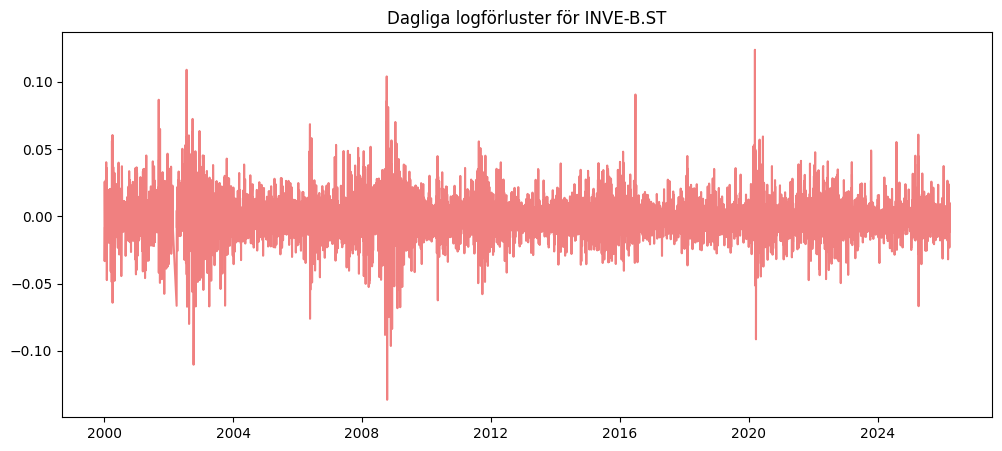

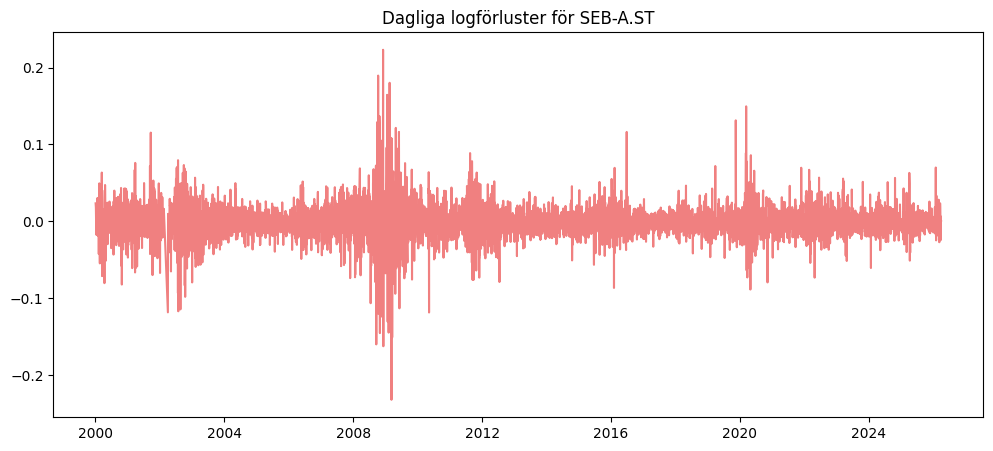

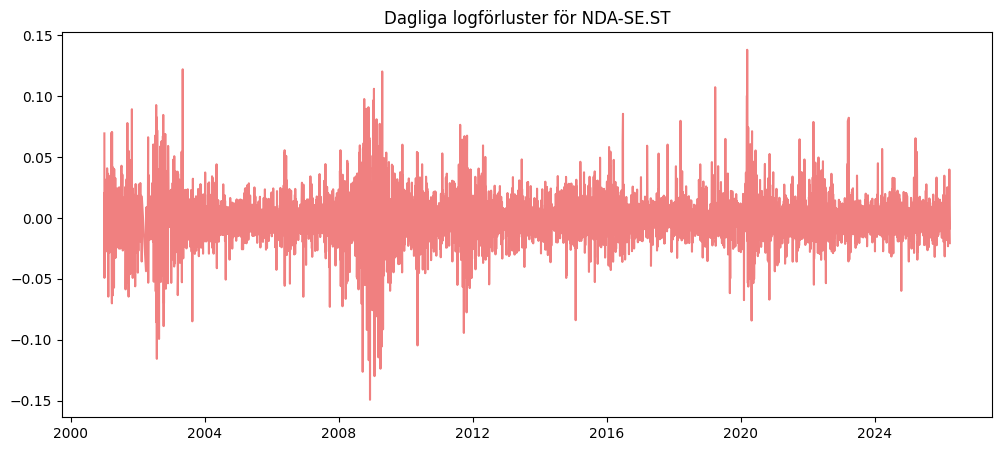

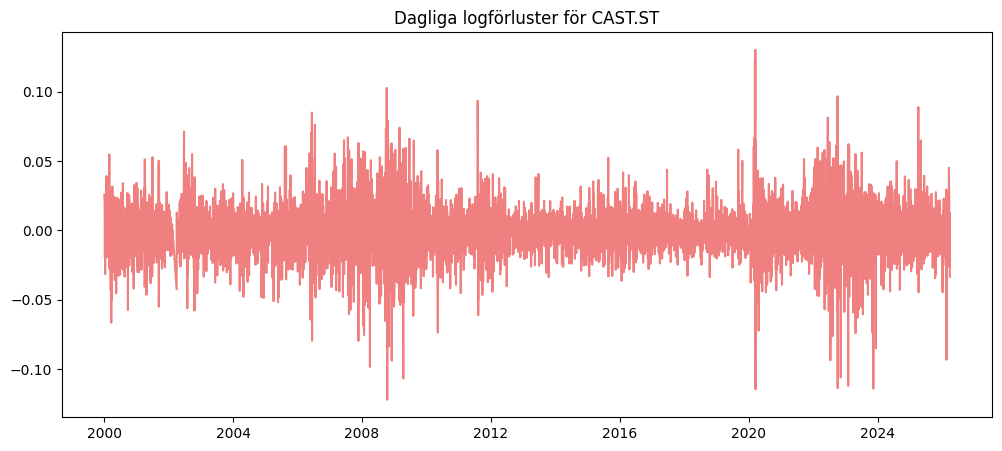

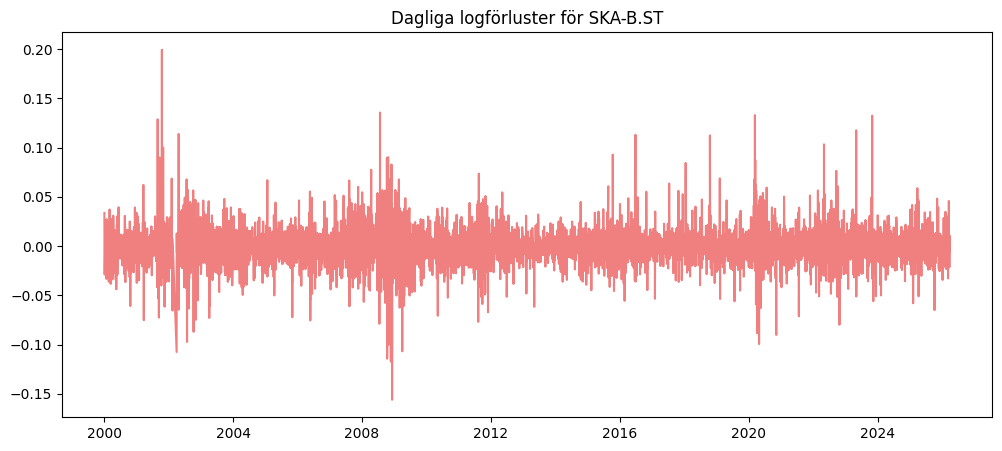

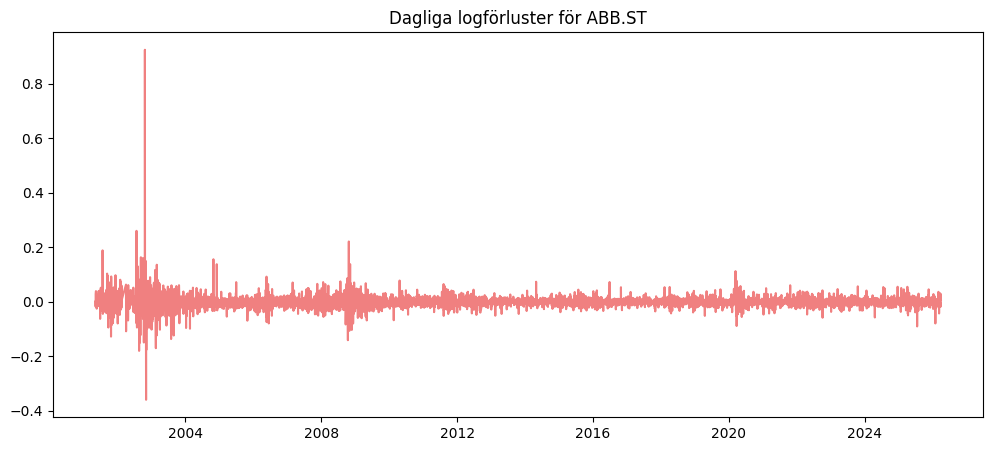

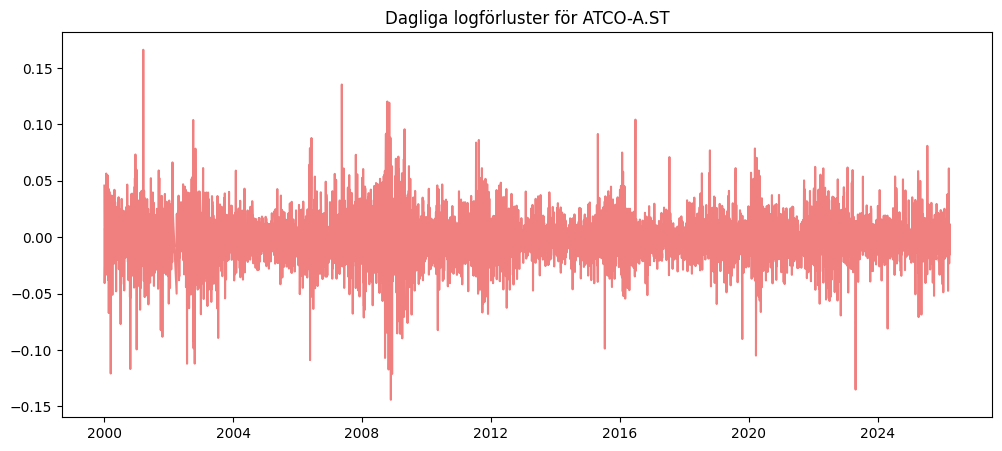

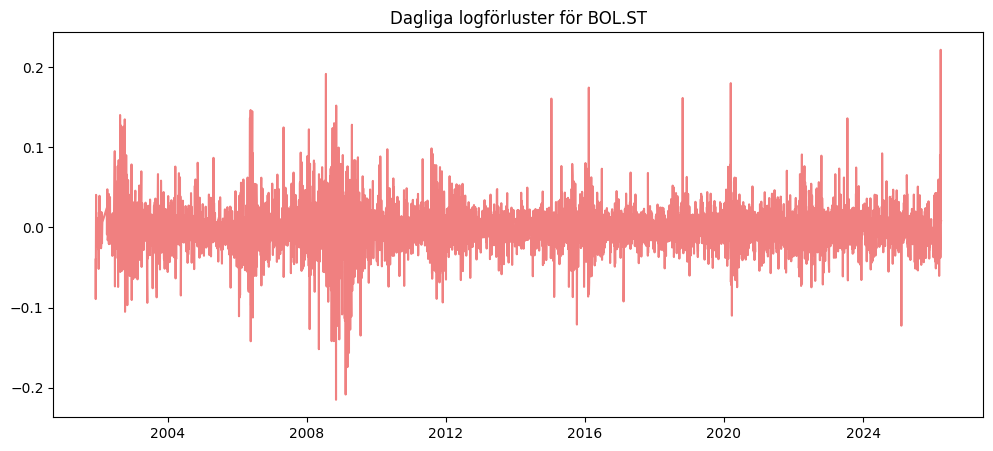

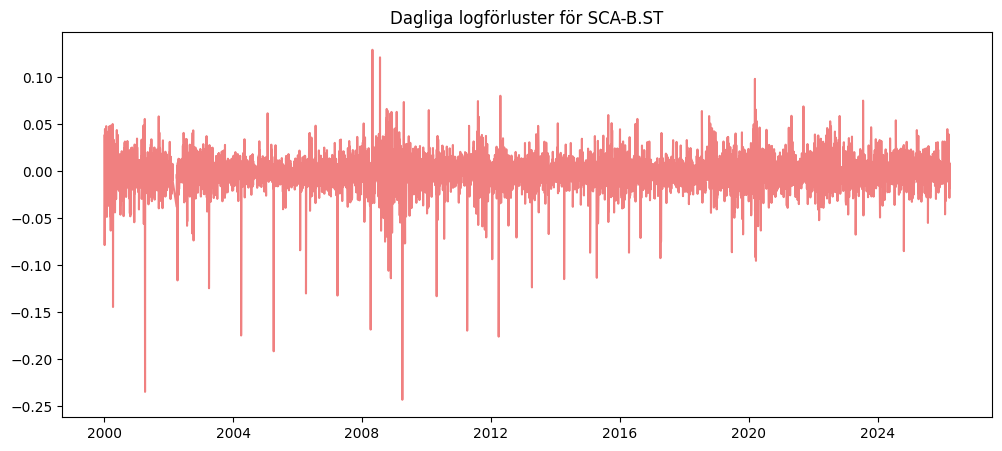

In [21]:
# Beräknar logförluster och sparar i en dict #
loglosses_dict = {}

for key in list(price_dict.keys()):
  df = price_dict[key]
  loglosses = -np.log(df["Close"]).diff().dropna()
  loglosses_dict[key] = loglosses

for key in list(loglosses_dict.keys()):
  plt.figure(figsize=(12,5))
  plt.plot(loglosses_dict[key], color="lightcoral")
  plt.title(f"Dagliga logförluster för {key}")
  plt.show()

In [22]:
# Splittar upp loglosses per eventgrupp

E_loglosses = {}
N_loglosses = {}

days = 5
j = 0 # Denna konstant lägger till j dagar till assymetriskt till fönster, till höger

for key in list(loglosses_dict):
  temp_df = pd.DataFrame({'Log-förluster': loglosses_dict[key]})
  temp_df["Indicator value"] = 0

  idx = temp_df.index

  for report_date in list(date_dict[key]):

    pos = idx.searchsorted(report_date)

    start_pos = max(0, pos - days)
    end_pos = min(len(idx), pos + days + 1 + j)

    window_index = idx[start_pos:end_pos]

    temp_df.loc[window_index, "Indicator value"] = 1

  E_loglosses[key] = temp_df.loc[temp_df["Indicator value"] == 1, "Log-förluster"]
  N_loglosses[key] = temp_df.loc[temp_df["Indicator value"] == 0, "Log-förluster"]

In [24]:
def declustering(logreturns, threshold, r = 15):
  """
  Returnerar datumkluster, pandas-serie med alla klustermax ihop med sina respektiva datum och extremal index.
  """
  exceedances_idx = logreturns[logreturns > threshold].index

  clusters = {}

  i = 0
  k = 0 # klusterindex

  while i < len(exceedances_idx):
    cluster = [exceedances_idx[i]]
    j = i # pekare som håller reda på sista positionen i nuvarande kluster

    while j + 1 < len(exceedances_idx): # är nästa klusterposition ett giltigt index?
      gap = (exceedances_idx[j + 1] - exceedances_idx[j]).days - 1 # Antalet dagar mellan överskotten

      if gap < r:
        cluster.append(exceedances_idx[j + 1])
        j += 1
      else: # Annars, klustret är avslutat
        break

    clusters[k] = cluster
    k += 1
    i = j + 1 # Flytta fram pekaren till nästa kluster

  declustered_dict = {}
  for key in clusters:
    cluster = clusters[key]
    cluster_vals = logreturns[cluster]

    max_val = cluster_vals.max() # max-värde
    max_idx = cluster_vals.idxmax() # max-index i cluster
    declustered_dict[max_idx] = max_val

  extremal_index = len(clusters) / len(exceedances_idx)

  return clusters, pd.Series(declustered_dict), extremal_index

In [28]:
# Här hittar vi respektive kvantiler
thresholds = {}
for key in list(loglosses_dict.keys()):
  thresholds[key] = loglosses_dict[key].quantile(0.94)
  print(f"Threshold för {key} är: {thresholds[key]}")
  print(f"Threshold för {key} är: EVENT: {E_loglosses[key].quantile(0.95)}, ICKE-EVENT: {N_loglosses[key].quantile(0.95)}")

Threshold för INVE-B.ST är: 0.023791561219988124
Threshold för INVE-B.ST är: EVENT: 0.023986127611786298, ICKE-EVENT: 0.0257924450103176
Threshold för SEB-A.ST är: 0.02817101244381126
Threshold för SEB-A.ST är: EVENT: 0.031248077866216122, ICKE-EVENT: 0.031324465781255556
Threshold för NDA-SE.ST är: 0.026830801580791198
Threshold för NDA-SE.ST är: EVENT: 0.027911080629043086, ICKE-EVENT: 0.029085020043036973
Threshold för CAST.ST är: 0.026051271594644362
Threshold för CAST.ST är: EVENT: 0.029857311037917663, ICKE-EVENT: 0.028355700401817452
Threshold för SKA-B.ST är: 0.02542877838396019
Threshold för SKA-B.ST är: EVENT: 0.030853927388355684, ICKE-EVENT: 0.027452954461749224
Threshold för ABB.ST är: 0.027398772182453256
Threshold för ABB.ST är: EVENT: 0.02830773810795263, ICKE-EVENT: 0.030999901470696735
Threshold för ATCO-A.ST är: 0.03032303607970076
Threshold för ATCO-A.ST är: EVENT: 0.03259461235001543, ICKE-EVENT: 0.03249766753991698
Threshold för BOL.ST är: 0.03683097320398858
Thre

In [ ]:
## Global declustering

# Declustering
extr_ind_dict = {}
cluster_dict = {}
maxima_dict = {}
exceedances = {}
excesses_E = {}
excesses_N = {}
for key in list(loglosses_dict.keys()):
  clusters, cluster_maximas, _ = declustering(loglosses_dict[key], thresholds[key], r=15)
  print(f"Antalet händelser totalt, för {key} är: {len(clusters)}")

  cluster_list = []
  for date in cluster_maximas.index:
    if date in E_loglosses[key].index:
      cluster_list.append(date)

  exc_count_E = ((E_loglosses[key] > thresholds[key]).to_numpy()).sum()
  exc_count_N = ((N_loglosses[key] > thresholds[key]).to_numpy()).sum()


  extr_idx_E = len(cluster_list) / exc_count_E
  extr_idx_N = (len(clusters) - len(cluster_list)) / exc_count_N

  extr_ind_dict[key] = (extr_idx_E, extr_idx_N) # (event, non-event)

  cluster_dict[key] = clusters
  maxima_dict[key] = cluster_maximas

  idx_E = pd.Index(cluster_list) # window extreme count
  obs_E = maxima_dict[key].loc[idx_E] # "iid" observations in the event group
  obs_N = maxima_dict[key].drop(idx_E) # "iid" observations in the non-event group

  excesses_E[key] = obs_E - thresholds[key] # pd series
  excesses_N[key] = obs_N - thresholds[key] # pd series

  print(f"Extremal index, {key}, event: {extr_idx_E}")
  print(f"Extremal index, {key} icke-event: {extr_idx_N}")
  print(f"Antalet händelser för {key} i eventgrupp: {excesses_E[key].count()}")
  print("----------------------------------------------------")

Antalet händelser totalt, för INVE-B.ST är: 129
Extremal index, INVE-B.ST, event: 0.4166666666666667
Extremal index, INVE-B.ST icke-event: 0.3123123123123123
Antalet händelser för INVE-B.ST i eventgrupp: 25
----------------------------------------------------
Antalet händelser totalt, för SEB-A.ST är: 134
Extremal index, SEB-A.ST, event: 0.4482758620689655
Extremal index, SEB-A.ST icke-event: 0.32238805970149254
Antalet händelser för SEB-A.ST i eventgrupp: 26
----------------------------------------------------
Antalet händelser totalt, för NDA-SE.ST är: 123
Extremal index, NDA-SE.ST, event: 0.5961538461538461
Extremal index, NDA-SE.ST icke-event: 0.2822085889570552
Antalet händelser för NDA-SE.ST i eventgrupp: 31
----------------------------------------------------
Antalet händelser totalt, för CAST.ST är: 132
Extremal index, CAST.ST, event: 0.45161290322580644
Extremal index, CAST.ST icke-event: 0.31419939577039274
Antalet händelser för CAST.ST i eventgrupp: 28
----------------------

In [ ]:
# Z-test med poolad parameter lambda
for key in loglosses_dict.keys():
  curr_cluster_len = len(cluster_dict[key])
  curr_max = maxima_dict[key]

  K_E = len(excesses_E[key])
  K_N = len(excesses_N[key])

  n_E = E_loglosses[key].count()
  n_N = N_loglosses[key].count()

  # Explicita proportioner/frekvenser för ett tvåproportioners z-test
  lambda_event = K_E / n_E
  lambda_nonevent = K_N / n_N

  lambda_pooled = (K_E + K_N) / (n_E + n_N) # här används en poolad parameter lambda för tvåproportionerstestet
  var_lambda_pool = lambda_pooled * (1 - lambda_pooled) * (1/n_E + 1/n_N) # poolad varians
  se_lambda = np.sqrt(var_lambda_pool)

  z_stat = (lambda_event - lambda_nonevent) / se_lambda # beräknar z-statistikan

  pval = stats.norm.sf(abs(z_stat)) * 2 # beräknar p-värdet ur z
  alpha = 0.05 # signifikansnivå

  # Results
  print(f"Current stock is {key}")
  print(f"K_E = {K_E}, K_N = {K_N}")
  print(f"lambda_event = {lambda_event:.6f}")
  print(f"lambda_nonevent = {lambda_nonevent:.6f}")
  print(f"Difference = {lambda_event - lambda_nonevent:+.6f}")
  print(f"z-stat = {z_stat:.4f}")
  print(f"p-value = {pval:.6g}")
  print(f"#-------# Z-test #-------#")
  if pval < alpha:
    print(f"Resultatet är: Signifikant")
  else:
    print(f"Resultatet är: Inte signifikant")

Current stock is INVE-B.ST
K_E = 25, K_N = 104
lambda_event = 0.021853
lambda_nonevent = 0.019284
Difference = +0.002569
z-stat = 0.5674
p-value = 0.570427
#-------# Z-test #-------#
Resultatet är: Inte signifikant
Current stock is SEB-A.ST
K_E = 26, K_N = 108
lambda_event = 0.027027
lambda_nonevent = 0.019365
Difference = +0.007662
z-stat = 1.5490
p-value = 0.121373
#-------# Z-test #-------#
Resultatet är: Inte signifikant
Current stock is NDA-SE.ST
K_E = 31, K_N = 92
lambda_event = 0.032225
lambda_nonevent = 0.017251
Difference = +0.014973
z-stat = 3.0884
p-value = 0.00201266
#-------# Z-test #-------#
Resultatet är: Signifikant
Current stock is CAST.ST
K_E = 28, K_N = 104
lambda_event = 0.029787
lambda_nonevent = 0.018585
Difference = +0.011203
z-stat = 2.2592
p-value = 0.0238685
#-------# Z-test #-------#
Resultatet är: Signifikant
Current stock is SKA-B.ST
K_E = 34, K_N = 115
lambda_event = 0.035752
lambda_nonevent = 0.020587
Difference = +0.015165
z-stat = 2.8966
p-value = 0.003

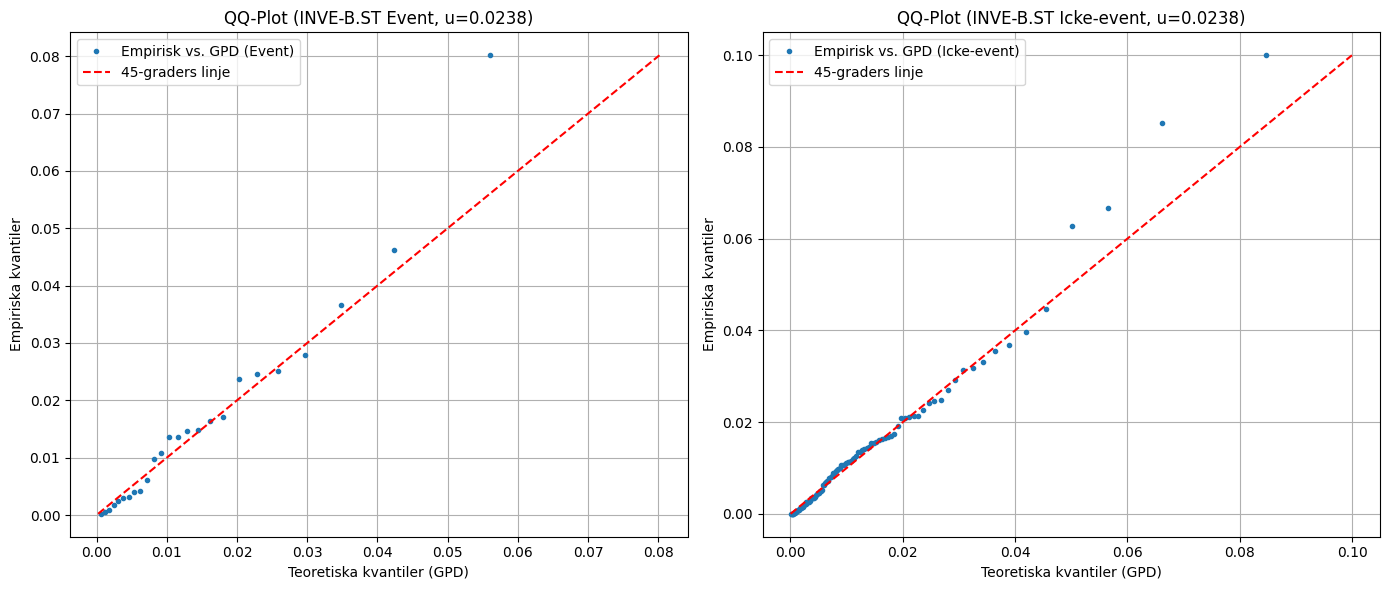

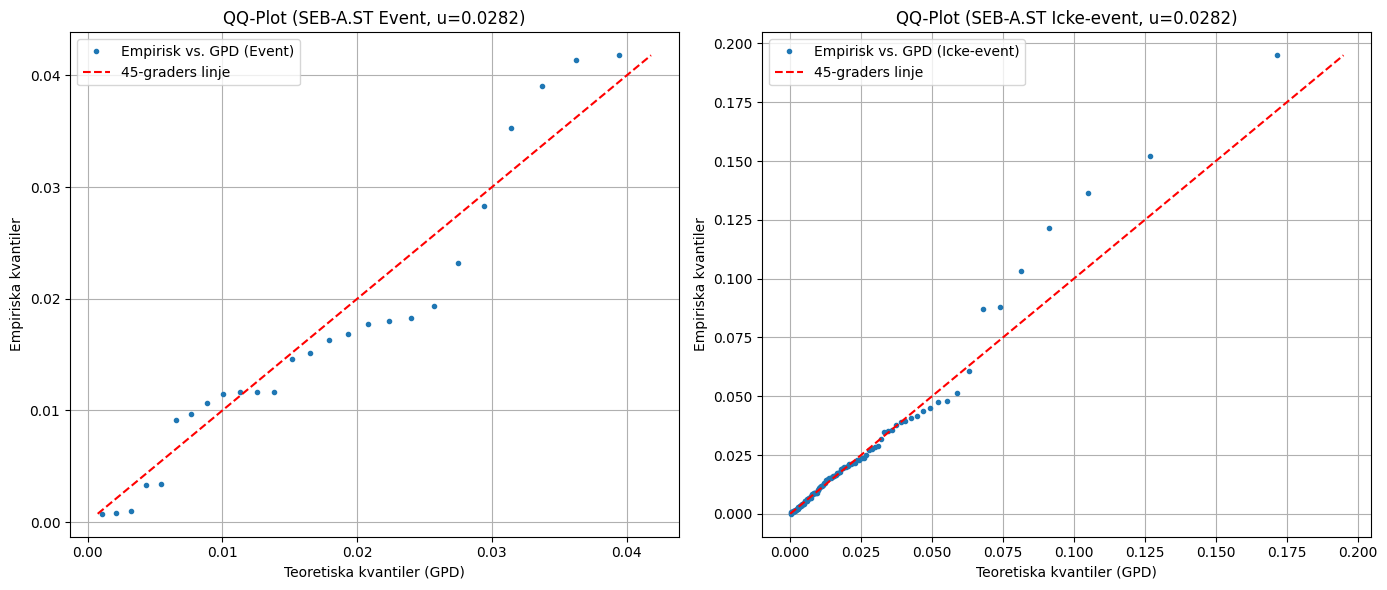

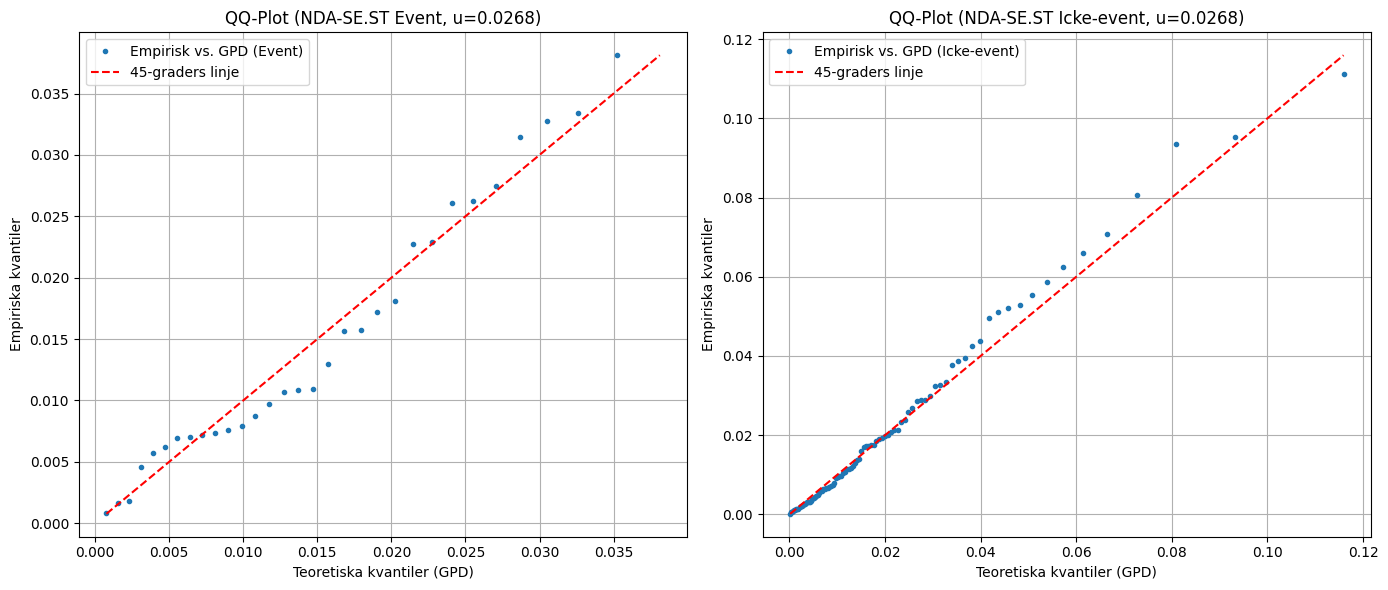

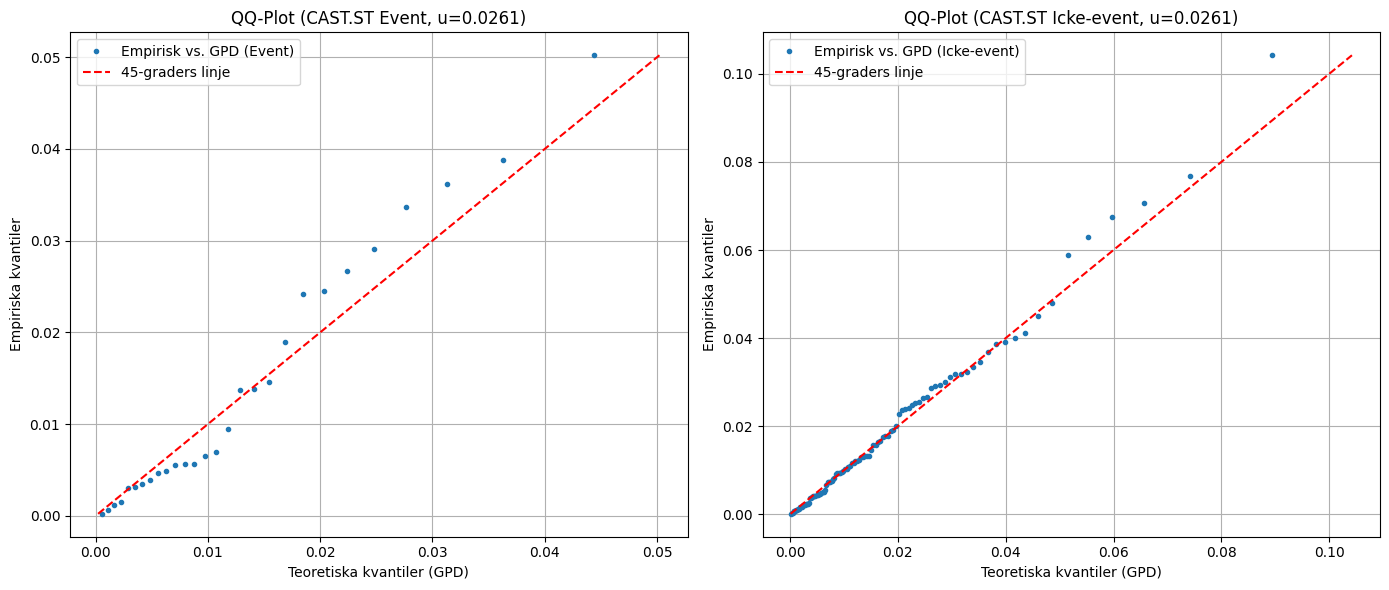

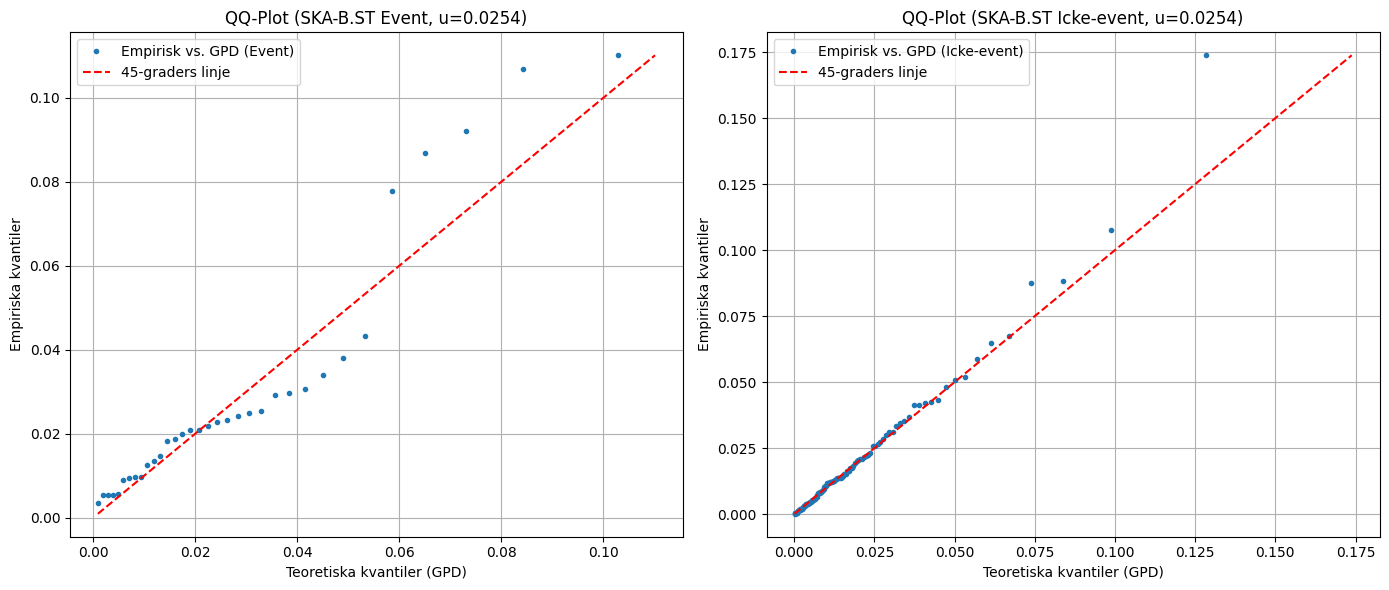

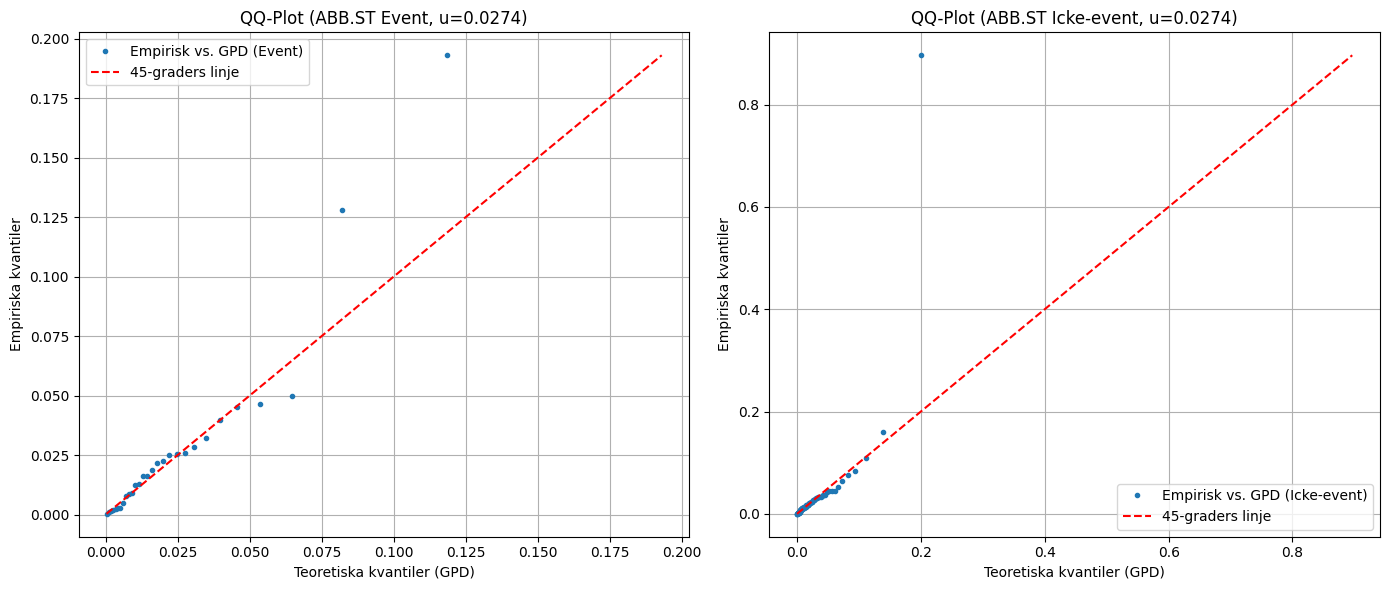

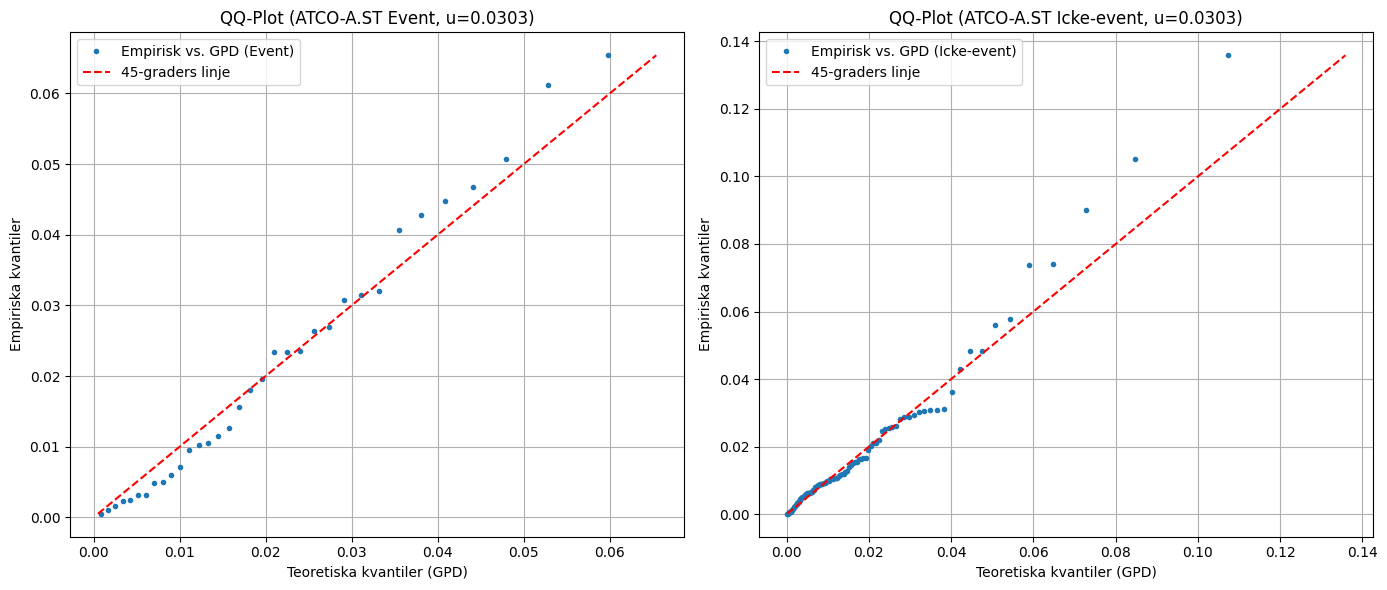

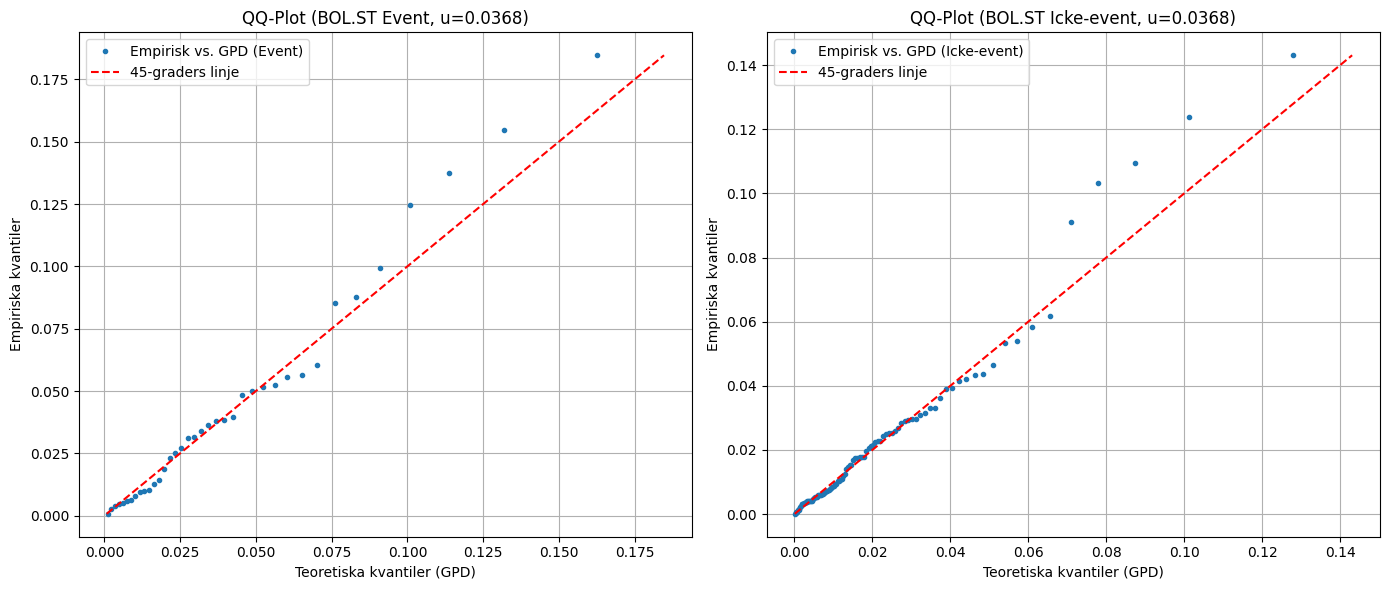

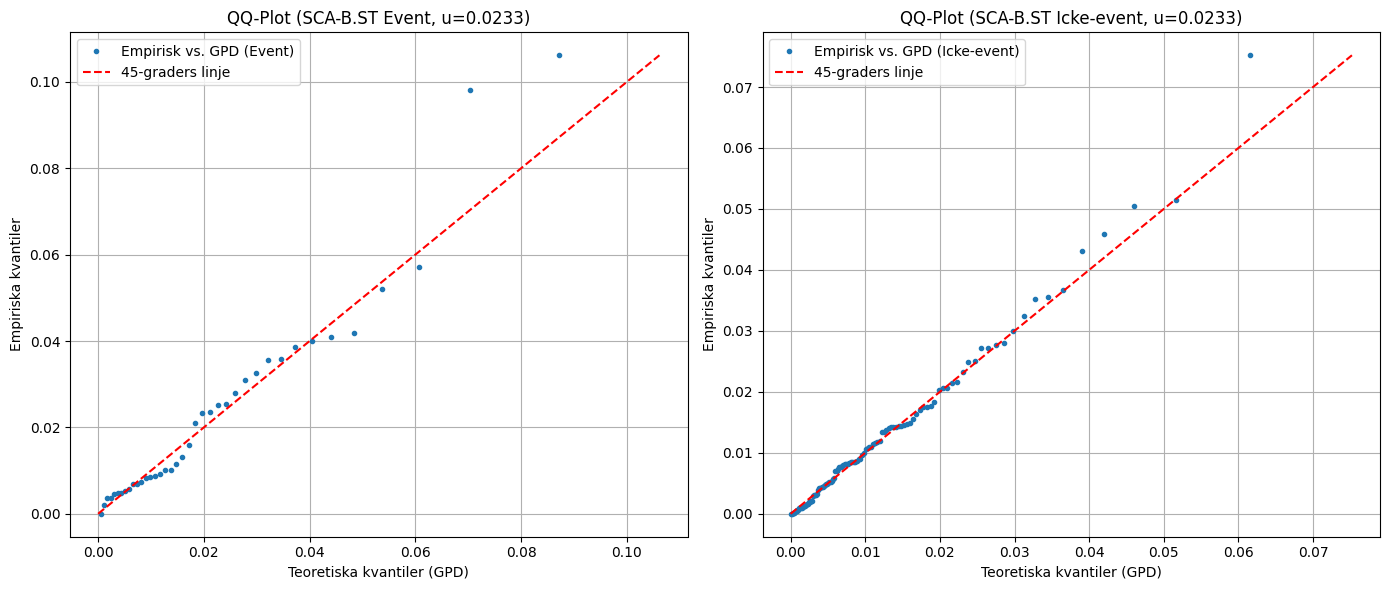

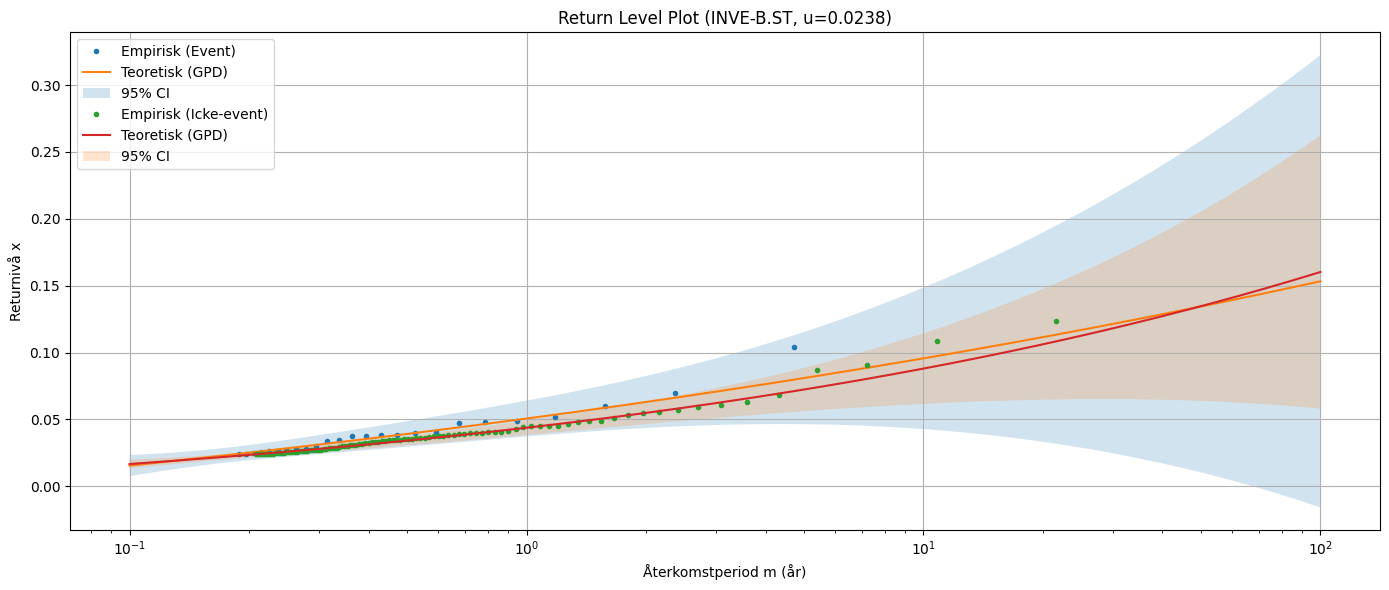

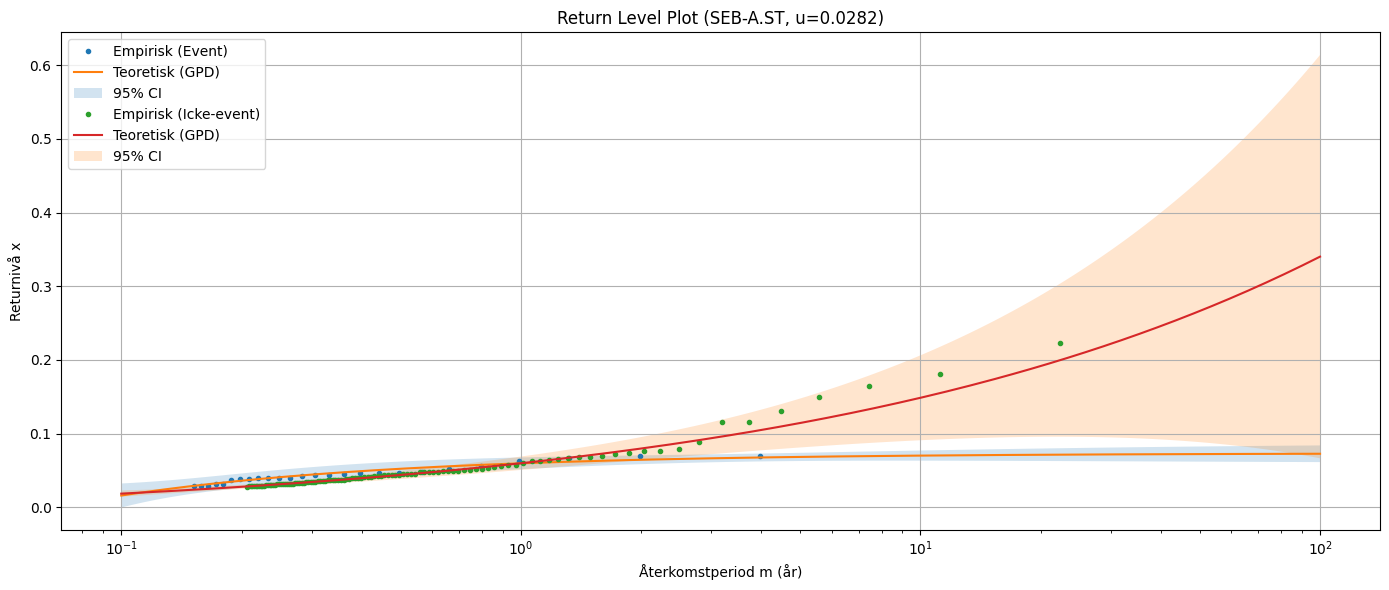

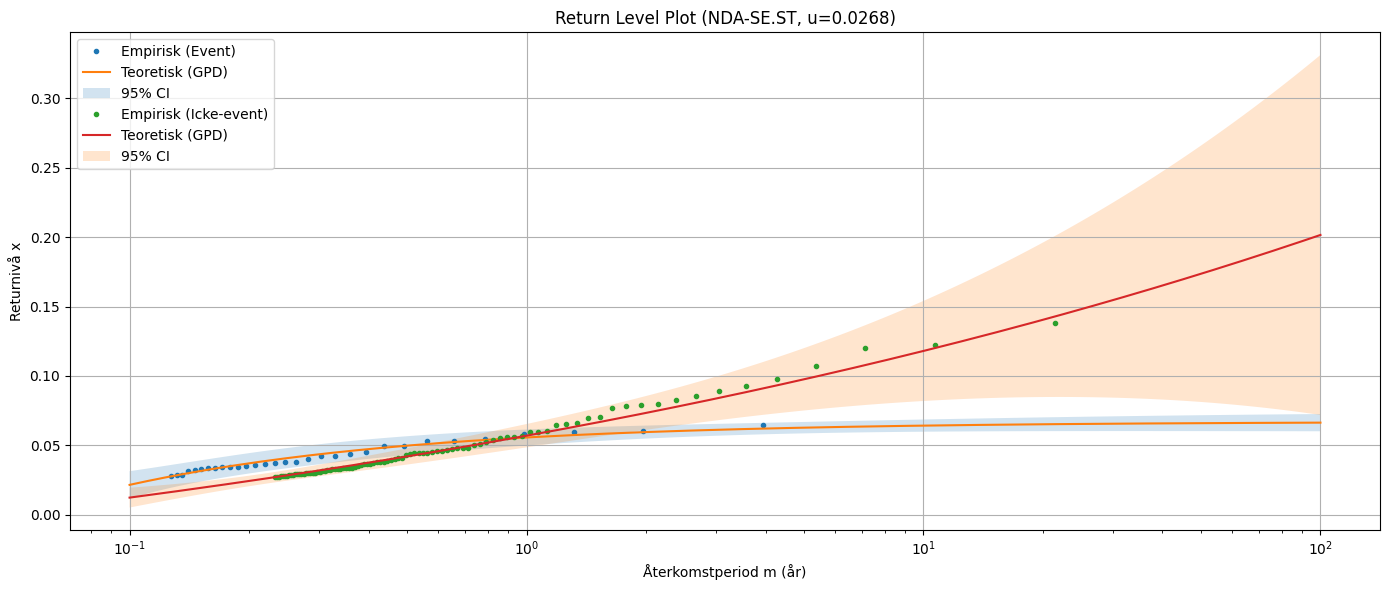

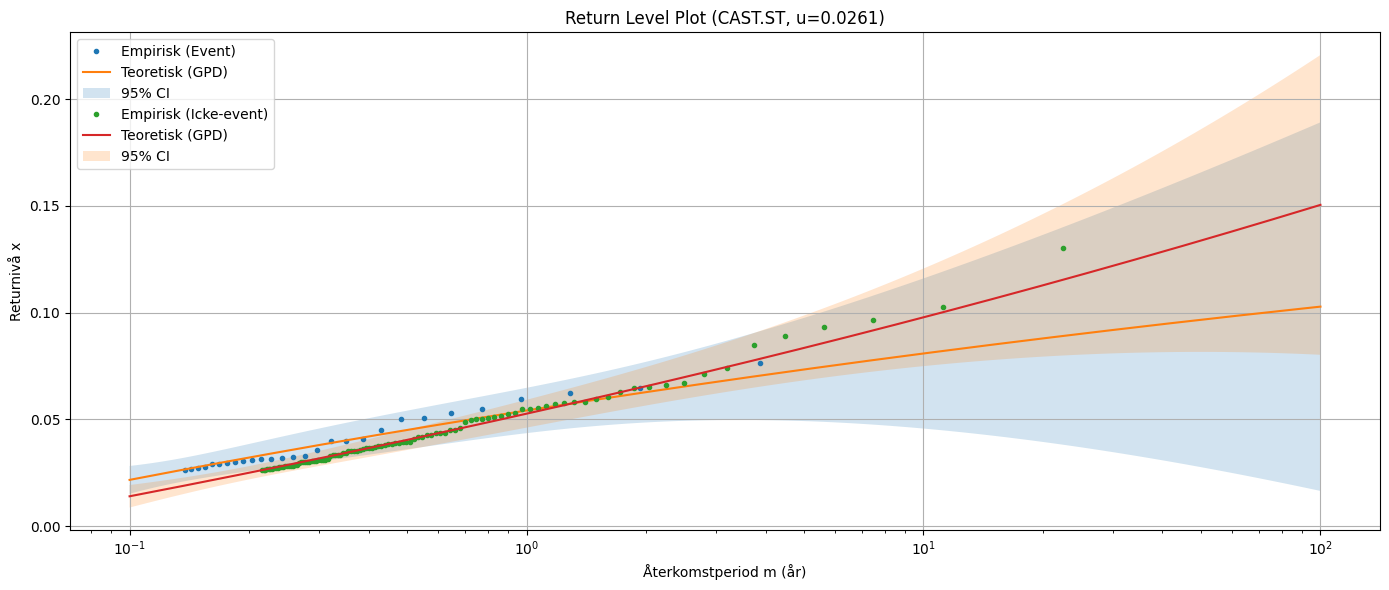

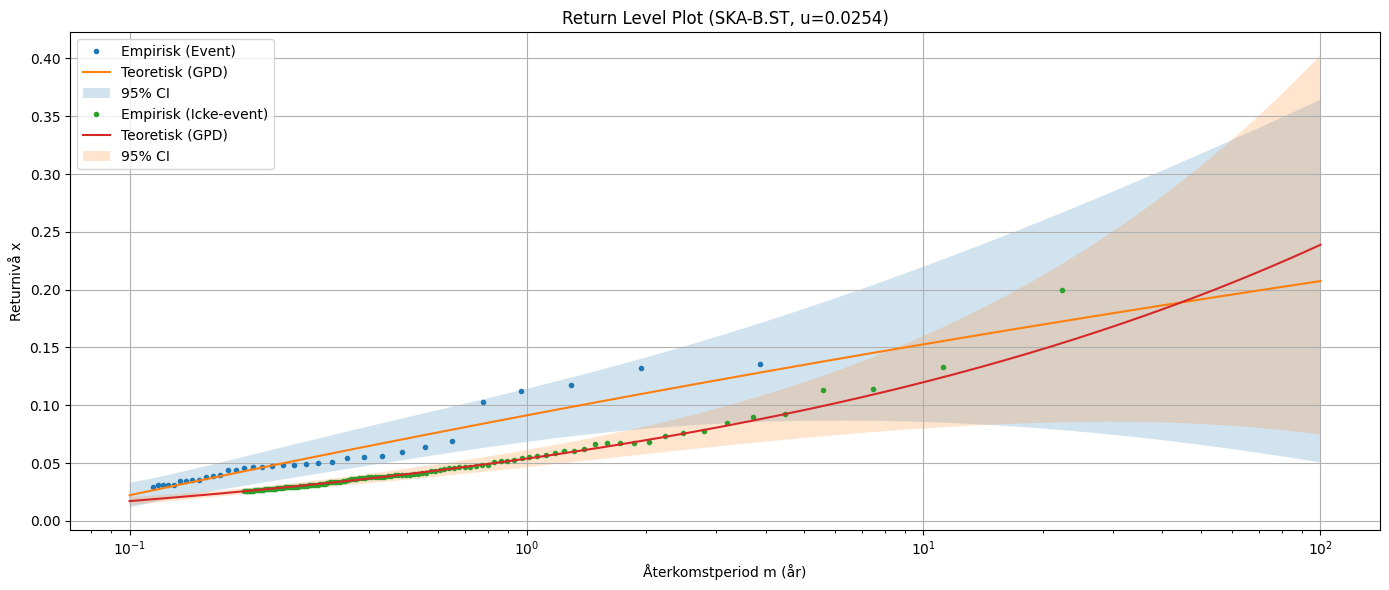

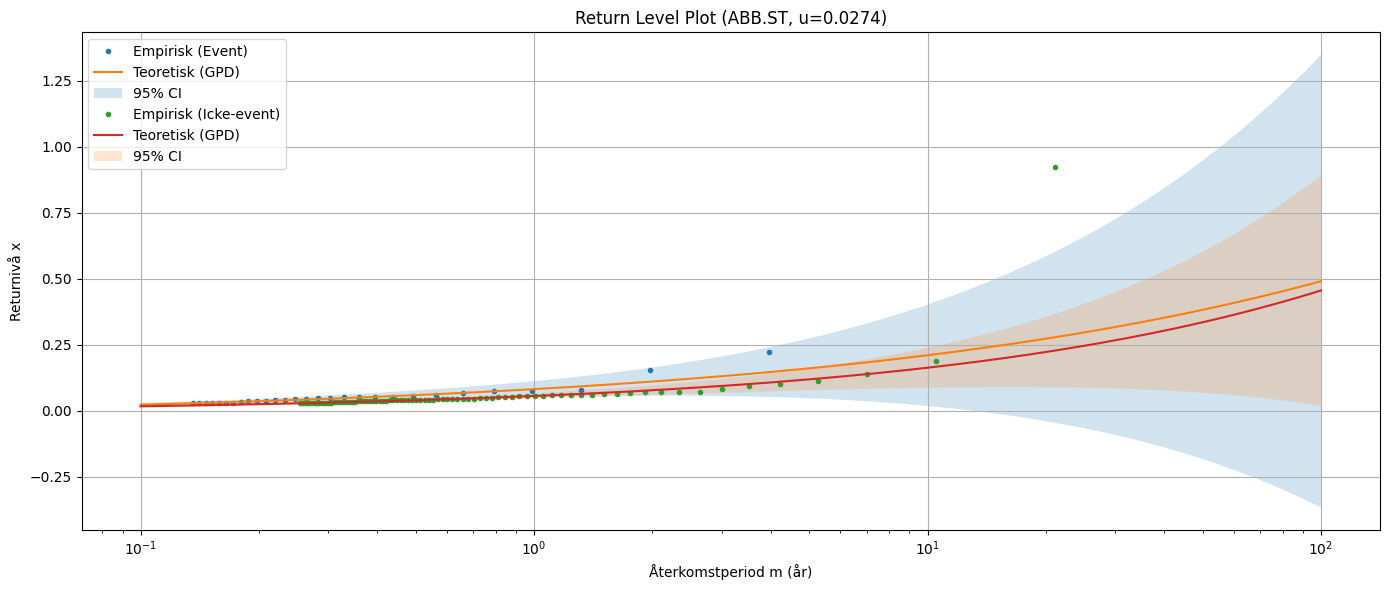

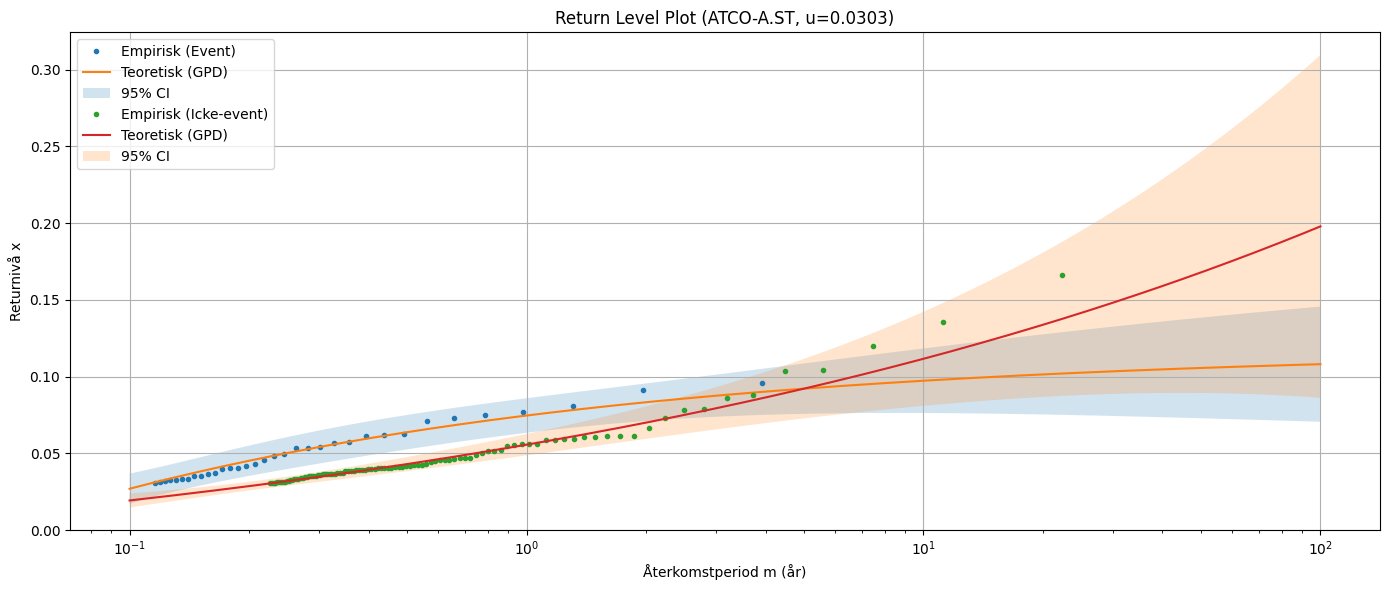

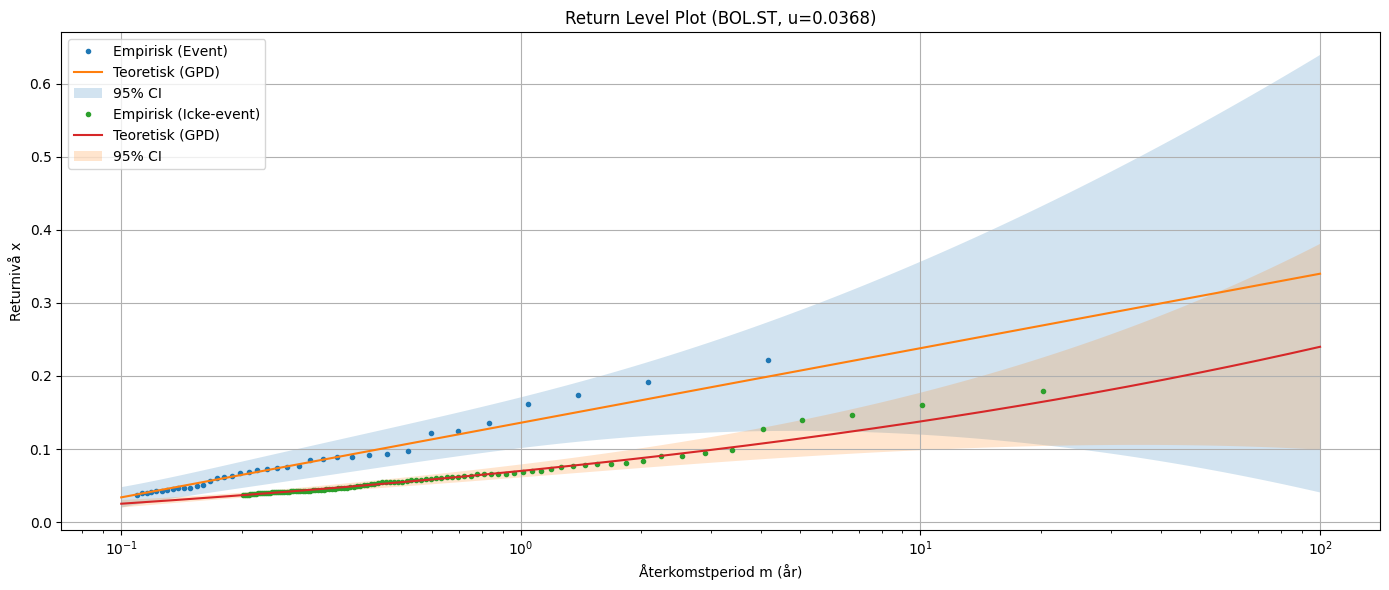

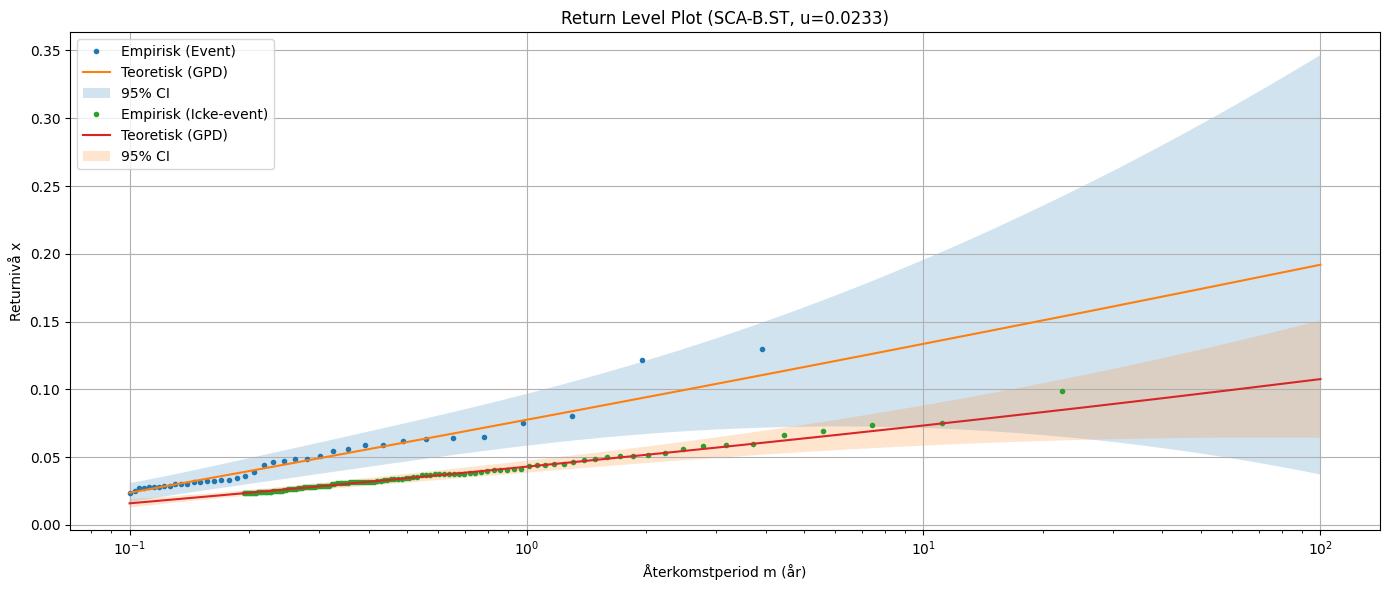

In [34]:
# I denna cellen är en del AI-genererat, exempelvis några funktioner, samt plottar för att effektivisera arbetet.
# Huvudsakliga teoretiska bitar är kontrollerade och allt material är AI-genererat på specifik förfrågan.

#===============================#
#-----------< GPD >-------------#
#===============================#

gpd_dict = {}
for key in excesses_E.keys():

  gpd_dict[key] = (stats.genpareto.fit(excesses_E[key], floc=0, method="MLE"), \
                   stats.genpareto.fit(excesses_N[key], floc=0, method="MLE"))


## Kommentera ut för att se parametrars värde per event och aktie
# for key in gpd_dict.keys():
#   print(f"GPD results for {key}")
#   print(f"Event window xi={gpd_dict[key][0][0]} and sigma={gpd_dict[key][0][2]}")
#   print(f"Non event window xi={gpd_dict[key][1][0]} and sigma={gpd_dict[key][1][2]}")
#   print("---------------------------------------------------------------------------")

#===============================#
#---------< QQ-plot >-----------#
#===============================#

# QQ-Plot för Event
for key in excesses_E.keys():
  plt.figure(figsize=(14, 6))
  plt.subplot(1, 2, 1)

  yE = excesses_E[key]
  yE_sorted = np.sort(yE)
  prob_E = np.arange(1, len(yE) + 1, dtype=int) / (len(yE) + 1) # Detta motsvarar i/(n+1)-punkterna i Coles

  qE_theoretical = stats.genpareto.ppf(prob_E, gpd_dict[key][0][0], loc=0, scale=gpd_dict[key][0][2]) # invers till cdf

  min_val = min(qE_theoretical.min(), yE_sorted.min())
  max_val = max(qE_theoretical.max(), yE_sorted.max())

  plt.plot(qE_theoretical, yE_sorted, 'o', markersize=3, label='Empirisk vs. GPD (Event)')
  plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', label='45-graders linje')
  plt.title(f'QQ-Plot ({key} Event, u={thresholds[key]:.4f})')
  plt.xlabel('Teoretiska kvantiler (GPD)')
  plt.ylabel('Empiriska kvantiler')
  plt.legend()
  plt.grid(True)

  # QQ-Plot för Non-Event
  plt.subplot(1, 2, 2)

  yN = excesses_N[key]
  yN_sorted = np.sort(yN)
  prob_N = np.arange(1, len(yN) + 1, dtype=int) / (len(yN) + 1) # Detta motsvarar i/(n+1)-punkterna i Coles

  qN_theoretical = stats.genpareto.ppf(prob_N, gpd_dict[key][1][0], loc=0, scale=gpd_dict[key][1][2]) # invers till cdf

  plt.plot(qN_theoretical, yN_sorted, 'o', markersize=3, label='Empirisk vs. GPD (Icke-event)')
  min_val = min(qN_theoretical.min(), yN_sorted.min())
  max_val = max(qN_theoretical.max(), yN_sorted.max())
  plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', label='45-graders linje')
  plt.title(f'QQ-Plot ({key} Icke-event, u={thresholds[key]:.4f})')
  plt.xlabel('Teoretiska kvantiler (GPD)')
  plt.ylabel('Empiriska kvantiler')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()




#===============================#
#------< Return levels >--------#
#===============================#

def gpd_negloglik(params, excesses):
    """Denna funktionen beräknar negative log-likelihooden. Genererad av AI."""

    sigma, xi = params
    y = np.asarray(excesses, dtype=float)
    k = len(y)
    if sigma <= 0:
        return np.inf
    if abs(xi) < 1e-6:
        return k * np.log(sigma) + np.sum(y) / sigma
    z = 1 + xi * y / sigma
    if np.any(z <= 0):
        return np.inf
    return k * np.log(sigma) + (1 + 1 / xi) * np.sum(np.log(z))

def numerical_hessian(func, params, excesses, h):
    """Denna funktionen beräknar en numerisk hessian. Genererad av AI."""

    params = np.asarray(params, dtype=float)
    n = len(params)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = h
            ej[j] = h
            fpp = func(params + ei + ej, excesses)
            fpm = func(params + ei - ej, excesses)
            fmp = func(params - ei + ej, excesses)
            fmm = func(params - ei - ej, excesses)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * h * h)
    return H

def gpd_cov_matrix(excesses, sigma_hat, xi_hat, h=1e-4):
    """Denna funktionen beräknar kovariansmatrisen. Genererad av AI."""
    H = numerical_hessian(gpd_negloglik, np.array([sigma_hat, xi_hat]), excesses, h=h)
    return np.linalg.inv(H)

def return_level_hat(u, sigma_hat, xi_hat, rate, m):
    """Beräknar return level givet parametrar."""
    if abs(xi_hat) > 1e-6:
        return u + (sigma_hat / xi_hat) * ((m * rate) ** xi_hat - 1)
    return u + sigma_hat * np.log(m * rate)

def return_level_se(u, sigma_hat, xi_hat, rate, n_total, cov_mat, m):
    """Return level standardfel för att plotta konfidensintervall."""
    mr = m * rate
    var_rate = rate * (1 - rate) / n_total

    if abs(xi_hat) > 1e-6:
        d_rate = sigma_hat * m * (mr ** (xi_hat - 1))
        d_sigma = ((mr ** xi_hat) - 1) / xi_hat
        d_xi = -(sigma_hat / xi_hat**2) * ((mr ** xi_hat) - 1) + (sigma_hat / xi_hat) * (mr ** xi_hat) * np.log(mr)
    else:
        d_rate = sigma_hat / rate
        d_sigma = np.log(mr)
        d_xi = 0.5 * sigma_hat * (np.log(mr) ** 2)

    # Gradient
    grad = np.array([d_rate, d_sigma, d_xi])

    # Varians-kovariansmatrisen
    V = np.array([
        [var_rate, 0.0, 0.0],
        [0.0, cov_mat[0, 0], cov_mat[0, 1]],
        [0.0, cov_mat[1, 0], cov_mat[1, 1]]
    ])

    var_xm = grad @ V @ grad 
    return np.sqrt(var_xm)

covE_dict = {}
covN_dict = {}
for key in cluster_dict.keys():
    plt.figure(figsize=(14, 6))

    nE = E_loglosses[key].count()
    nN = N_loglosses[key].count()

    kE = excesses_E[key].count()
    kN = excesses_N[key].count()

    rate_E = kE / nE
    rate_N = kN / nN

    #plt.subplot(1, 2, 1)
    yE = np.asarray(excesses_E[key], dtype=float)
    yE_sorted = np.sort(yE)
    xE_sorted = thresholds[key] + yE_sorted

    iE = np.arange(1, kE + 1)
    pE_tail = (kE + 1 - iE) / (kE + 1)
    mE_emp = 1 / (pE_tail * rate_E)

    plt.semilogx(mE_emp/252, xE_sorted, 'o', markersize=3, label='Empirisk (Event)')

    xiE_hat = gpd_dict[key][0][0]
    sigmaE_hat = gpd_dict[key][0][2]
    covE_dict[key] = gpd_cov_matrix(yE, sigmaE_hat, xiE_hat)

    m_max_years = 100
    m_grid_E = np.logspace(np.log10(0.1 * 252), np.log10(m_max_years * 252), 200)

    xE_th = np.array([return_level_hat(thresholds[key], sigmaE_hat, xiE_hat, rate_E, m) for m in m_grid_E])
    seE = np.array([return_level_se(thresholds[key], sigmaE_hat, xiE_hat, rate_E, nE, covE_dict[key], m) for m in m_grid_E])

    plt.semilogx(m_grid_E/252, xE_th, '-', label='Teoretisk (GPD)')
    plt.fill_between(m_grid_E/252, xE_th - 1.96 * seE, xE_th + 1.96 * seE, alpha=0.2, label='95% CI')

    # plt.title(f'Return Level Plot ({key} Event, u={thresholds[key]:.4f})')
    # plt.xlabel('Återkomstperiod m (år)')
    # plt.ylabel('Returnivå x')
    # plt.legend()
    # plt.grid(True)

    #plt.subplot(1, 2, 2)
    yN = np.asarray(excesses_N[key], dtype=float)
    yN_sorted = np.sort(yN)
    xN_sorted = thresholds[key] + yN_sorted

    iN = np.arange(1, kN + 1)
    pN_tail = (kN + 1 - iN) / (kN + 1)
    mN_emp = 1 / (rate_N * pN_tail)

    plt.semilogx(mN_emp/252, xN_sorted, 'o', markersize=3, label='Empirisk (Icke-event)')

    xiN_hat = gpd_dict[key][1][0]
    sigmaN_hat = gpd_dict[key][1][2]
    covN_dict[key] = gpd_cov_matrix(yN, sigmaN_hat, xiN_hat)

    m_max_plot_N = max(25200, np.max(mN_emp)) # extrapolationslängd
    m_grid_N = np.logspace(np.log10(0.1 * 252), np.log10(m_max_years * 252), 200)
    xN_th = np.array([return_level_hat(thresholds[key], sigmaN_hat, xiN_hat, rate_N, m) for m in m_grid_N])
    seN = np.array([return_level_se(thresholds[key], sigmaN_hat, xiN_hat, rate_N, nN, covN_dict[key], m) for m in m_grid_N])

    plt.semilogx(m_grid_N/252, xN_th, '-', label='Teoretisk (GPD)')
    plt.fill_between(m_grid_N/252, xN_th - 1.96 * seN, xN_th + 1.96 * seN, alpha=0.2, label='95% CI')

    plt.title(f'Return Level Plot ({key}, u={thresholds[key]:.4f})')
    plt.xlabel('Återkomstperiod m (år)')
    plt.ylabel('Returnivå x')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
# z-test för \Delta\xi i syfte att avgöra om nollhypotesen om lika magnitud i \xi över eventgrupperna, per aktie,
# går att förkasta. Om noll ligger i intervallet är evidens mot nollhypotesen inte tillräckliga.

xi_diff_ci = {}
for key in gpd_dict.keys():
  diff = gpd_dict[key][0][0] - gpd_dict[key][1][0]
  ste = np.sqrt(covE_dict[key][1,1] + covN_dict[key][1,1])
  lower = diff - 1.96 * ste
  upper = diff + 1.96 * ste
  xi_diff_ci[key] = (lower, upper)

for key in xi_diff_ci.keys():
  print(f"\n{key}")
  print(f"CI for Delta xi: [{xi_diff_ci[key][0]:+},{xi_diff_ci[key][1]:+}]")


INVE-B.ST
CI for Delta xi: [-0.6391214661524621,+0.42823220667339795]

SEB-A.ST
CI for Delta xi: [-1.5719583515232158,-0.3364944322754211]

NDA-SE.ST
CI for Delta xi: [-1.1919456718305939,-0.28386931858701325]

CAST.ST
CI for Delta xi: [-0.7423700366426997,+0.437674850595636]

SKA-B.ST
CI for Delta xi: [-0.7439075510957868,+0.13238474594276328]

ABB.ST
CI for Delta xi: [-0.6495144282285278,+0.45390670476607153]

ATCO-A.ST
CI for Delta xi: [-0.9647463466689465,-0.05684612646970749]

BOL.ST
CI for Delta xi: [-0.6294069674877689,+0.2707532216568205]

SCA-B.ST
CI for Delta xi: [-0.4266184302331615,+0.3592863221425441]


### Bootstrap-test för skillnad i svansindex mellan event- och icke-eventperioder

Koden implementerar ett parametriskt bootstrap-test för att undersöka om GPD-formparametern \(\xi\) skiljer sig mellan event- och icke-eventperioder. 

För varje aktie:
- skattas den observerade skillnaden
\Delta \xi = \xi_E - \xi_N,
- därefter skattas en poolad GPD under nollhypotesen
H_0: \xi_E = \xi_N,
- bootstrap-samplen genereras från denna poolade modell,
- och separata GPD-modeller återanpassas till varje bootstrap-sample.

Den empiriska bootstrapfördelningen för (\Delta \xi) används sedan för att approximera ett tvåsidigt p-värde samt ett bootstrapintervall under (H_0).

- Detta görs främst för att bekräfta resultatet från tidigare z-test

In [42]:
def bootstrap_delta_xi(key, n_boot=2000, conf_level=0.95):

    # Original fits under alternativet (för punktestimatet)
    xi_E_hat, _, scale_E_hat = gpd_dict[key][0]
    xi_N_hat, _, scale_N_hat = gpd_dict[key][1]

    # Observerad skillnad
    delta_hat = xi_E_hat - xi_N_hat

    # Poolad fit under H0: gemensam GPD för båda grupperna
    pooled_excesses = pd.concat([excesses_E[key], excesses_N[key]])
    xi_0_hat, _, scale_0_hat = stats.genpareto.fit(pooled_excesses, floc=0, method="MLE")

    delta_boot = np.zeros(n_boot)

    n_E = len(excesses_E[key])
    n_N = len(excesses_N[key])

    for i in range(n_boot):
        # Generera bootstrap-sample under H0 från samma poolade GPD
        boot_E = stats.genpareto.rvs(c=xi_0_hat, loc=0, scale=scale_0_hat, size=n_E)
        boot_N = stats.genpareto.rvs(c=xi_0_hat, loc=0, scale=scale_0_hat, size=n_N)

        # Re-fit separat på bootstrap-samplen
        xi_E_star = stats.genpareto.fit(boot_E, floc=0, method="MLE")[0]
        xi_N_star = stats.genpareto.fit(boot_N, floc=0, method="MLE")[0]

        delta_boot[i] = xi_E_star - xi_N_star

    # Tvåsidigt bootstrap-p-värde under H0
    p_value = np.mean(np.abs(delta_boot) >= np.abs(delta_hat))

    # Om du ändå vill skriva ut ett "testintervall" under H0:
    alpha = (1 - conf_level) / 2
    ci_low  = np.percentile(delta_boot, alpha * 100)
    ci_high = np.percentile(delta_boot, (1 - alpha) * 100)

    print(f"\n{key} – Skillnad i tail index ( xi_event - xi_non-event)")
    print(f"  Skattning från observerad data: {delta_hat:+.4f}")
    print(f"  Poolad H0-fit:  xi0 = {xi_0_hat:+.4f},  sigma0 = {scale_0_hat:+.4f}")
    print(f"  Bootstrapintervall under H0: [{ci_low:+.4f}, {ci_high:+.4f}]")
    print(f"  p-värde (tvåsidigt test H₀: Δξ = 0): {p_value:.4f}")

    if p_value < 0.05:
        if delta_hat > 0:
            print("  → Signifikant tyngre svans i event-fönstret")
        else:
            print("  → Signifikant tunnare svans i event-fönstret")
    else:
        print("  → Ingen statistiskt signifikant skillnad i tail-heaviness")

    print("-----------------------------------------------------------------")

    return delta_hat, ci_low, ci_high, p_value


delta_hat_dict = {}
ci_dict = {}
p_value_dict = {}

for key in gpd_dict.keys():
    delta_hat, ci_low, ci_high, p_value = bootstrap_delta_xi(key)
    delta_hat_dict[key] = delta_hat
    ci_dict[key] = (ci_low, ci_high)
    p_value_dict[key] = p_value


INVE-B.ST – Skillnad i tail index ( xi_event - xi_non-event)
  Skattning från observerad data: -0.1054
  Poolad H0-fit:  xi0 = +0.1970,  sigma0 = +0.0113
  Bootstrapintervall under H0: [-0.7687, +0.5031]
  p-värde (tvåsidigt test H₀: Δξ = 0): 0.7365
  → Ingen statistiskt signifikant skillnad i tail-heaviness
-----------------------------------------------------------------

SEB-A.ST – Skillnad i tail index ( xi_event - xi_non-event)
  Skattning från observerad data: -0.9542
  Poolad H0-fit:  xi0 = +0.2527,  sigma0 = +0.0159
  Bootstrapintervall under H0: [-0.7890, +0.5179]
  p-värde (tvåsidigt test H₀: Δξ = 0): 0.0125
  → Signifikant tunnare svans i event-fönstret
-----------------------------------------------------------------

NDA-SE.ST – Skillnad i tail index ( xi_event - xi_non-event)
  Skattning från observerad data: -0.7379
  Poolad H0-fit:  xi0 = +0.0792,  sigma0 = +0.0181
  Bootstrapintervall under H0: [-0.6797, +0.4389]
  p-värde (tvåsidigt test H₀: Δξ = 0): 0.0190
  → Signi